# Stage 07 — Explain and validate the chosen model (article mean)
The model is transparent: forecast = the article's average weekly units per store in training. SHAP/PDP add nothing;
the useful checks are where it is wrong, whether it is calibrated, and how stable the article levels are.

In [1]:
import sys, json
sys.path.insert(0, "../../plugins/dslc/skills/dslc/scripts")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from dslc_style import apply_style, SERIES, INK, save
apply_style()
p = pd.read_parquet("data/processed/weekly_panel.parquet")
tr = p[p.split == "train"]
t = pd.read_csv("reports/tables/06_test_predictions.csv", parse_dates=["week"]).merge(p[["SITE_NAME", "ARTICLE", "week", "division", "shelf_life_days", "storage"]], on=["SITE_NAME", "ARTICLE", "week"])
t["ae"] = (t.units - t.pred).abs(); t["err"] = t.pred - t.units
def seg(col):
    g = t.groupby(col).agg(units=("units", "sum"), pred=("pred", "sum"), ae=("ae", "sum"), n=("units", "size"))
    g["wape"] = g.ae / g.units; g["bias"] = (g.pred - g.units) / g.units; return g.round(3)

## Where is it wrong?

In [2]:
for c in ["division", "SITE_NAME", "storage"]:
    print(seg(c).to_string(), "\n")
a = seg("ARTICLE").sort_values("wape"); print(a.to_string())
a.to_csv("reports/tables/07_error_by_article.csv")
t["vol_band"] = pd.qcut(t.pred, 4, labels=["lowest 25%", "25-50%", "50-75%", "top 25%"]); print(seg("vol_band").to_string())
print(seg(t.week.dt.to_period("M")).to_string())

               units      pred        ae    n   wape   bias
division                                                   
Dairy & Milk  4085.0  3763.333  2039.589  420  0.499 -0.079
Fruits        7440.0  7391.333  3272.233  720  0.440 -0.007
Vegetables    8220.0  8373.333  3356.789  600  0.408  0.019 

                    units    pred        ae    n   wape   bias
SITE_NAME                                                     
East Fresh Store   4348.0  3905.6  1891.233  348  0.435 -0.102
Metro Fresh Store  3671.0  3905.6  1623.778  348  0.442  0.064
RVM1 Fresh Store   4130.0  3905.6  1747.344  348  0.423 -0.054
RVM2 Fresh Store   3809.0  3905.6  1631.367  348  0.428  0.025
West Fresh Store   3787.0  3905.6  1774.889  348  0.469  0.031 

           units       pred        ae    n   wape   bias
storage                                                 
Ambient  11162.0  11296.333  4360.844  780  0.391  0.012
Chilled   8583.0   8231.667  4307.767  960  0.502 -0.041 

                       un

/var/folders/_s/s7hnymmn39d5ptgj1rb5wvy40000gn/T/ipykernel_35360/122763525.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = t.groupby(col).agg(units=("units", "sum"), pred=("pred", "sum"), ae=("ae", "sum"), n=("units", "size"))


## Calibration: do the P10–P90 bands hold for every store and division?

In [3]:
t["in80"] = (t.units >= t.p10) & (t.units <= t.p90); t["below_p80"] = t.units <= t.p80
print(t.groupby("SITE_NAME")[["in80", "below_p80"]].mean().round(3).to_string()); print(t.groupby("division")[["in80", "below_p80"]].mean().round(3).to_string())
# calibration of the point forecast: predicted-band vs actual mean
t["pbin"] = pd.qcut(t.pred, 8, duplicates="drop"); cal = t.groupby("pbin", observed=True).agg(pred=("pred", "mean"), actual=("units", "mean")).round(2); print(cal.to_string())

                    in80  below_p80
SITE_NAME                          
East Fresh Store   0.759      0.759
Metro Fresh Store  0.848      0.810
RVM1 Fresh Store   0.825      0.764
RVM2 Fresh Store   0.819      0.819
West Fresh Store   0.782      0.799
               in80  below_p80
division                      
Dairy & Milk  0.748      0.740
Fruits        0.796      0.792
Vegetables    0.860      0.823
                   pred  actual
pbin                           
(3.693, 5.078]     4.70    4.79
(5.078, 6.622]     6.03    6.60
(6.622, 8.206]     7.49    7.89
(8.206, 8.55]      8.38    8.41
(8.55, 9.444]      9.10    8.88
(9.444, 13.789]   12.77   13.72
(13.789, 19.461]  16.63   16.97
(19.461, 34.561]  28.45   27.22


## Stability: how much would the article levels have moved with a different window?

In [4]:
first = tr[tr.week < "2024-08-26"].groupby(["SITE_NAME", "ARTICLE"]).units.mean(); last = tr[tr.week >= "2024-08-26"].groupby(["SITE_NAME", "ARTICLE"]).units.mean()
allm = tr.groupby(["SITE_NAME", "ARTICLE"]).units.mean()
print("corr first-half vs second-half series means:", round(first.corr(last), 3))
te = p[p.split == "test"]
def wape(y, f): return float(np.abs(y - f).sum() / y.sum())
for name, m in [("all train", allm), ("first half of train only", first), ("second half of train only", last)]:
    f = te.set_index(["SITE_NAME", "ARTICLE"]).index.map(m).values; print(f"{name:28s} test WAPE {wape(te.units.values, f):.3f}")
# pooled across stores (article only) vs per store
am = tr.groupby("ARTICLE").units.mean(); print("article-pooled mean test WAPE:", round(wape(te.units.values, te.ARTICLE.map(am).values), 3))

corr first-half vs second-half series means: 0.96
all train                    test WAPE 0.444
first half of train only     test WAPE 0.450
second half of train only    test WAPE 0.449
article-pooled mean test WAPE: 0.439


## Fairness / sensitive groups
Not applicable: units are product-level counts, no individuals or protected attributes are modelled.

'figures/07_calibration.png'

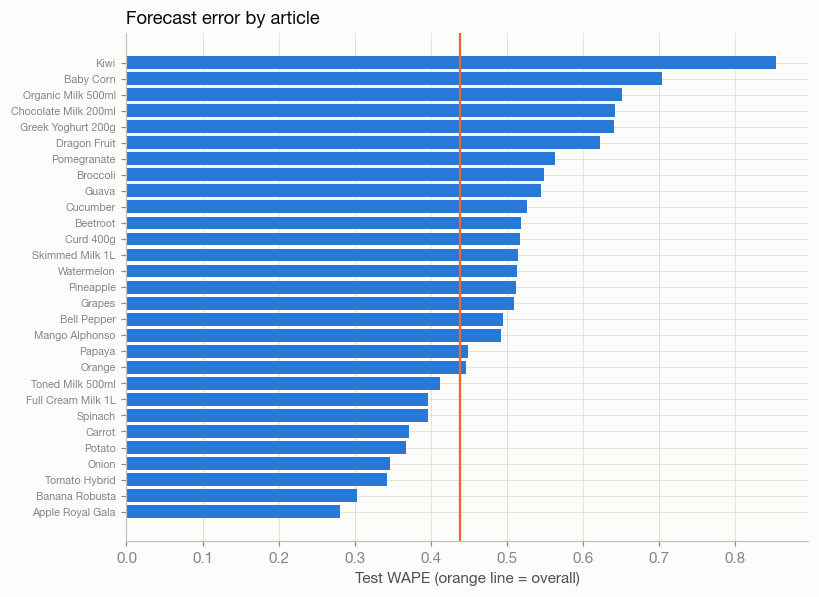

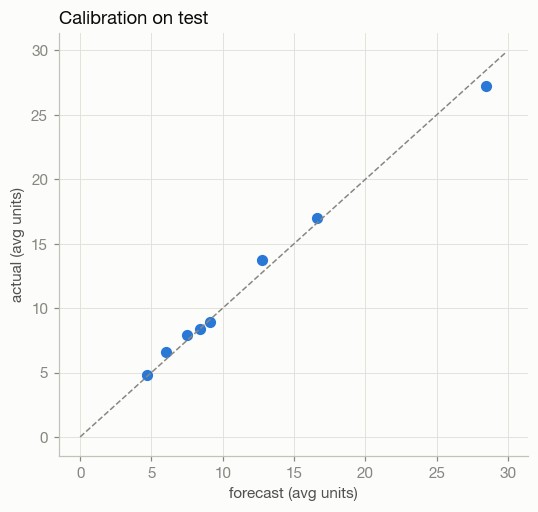

In [5]:
fig, ax = plt.subplots(figsize=(8, 6)); a2 = a.sort_values("wape")
ax.barh(a2.index, a2.wape, color=SERIES[0]); ax.axvline(t.ae.sum() / t.units.sum(), color=SERIES[1], lw=1.5); ax.tick_params(axis="y", labelsize=7)
ax.set_xlabel("Test WAPE (orange line = overall)"); ax.set_title("Forecast error by article"); save(fig, "07_error_article")
fig, ax = plt.subplots(figsize=(5.5, 5)); mx = max(cal.pred.max(), cal.actual.max()) * 1.05
ax.plot([0, mx], [0, mx], color=INK["muted"], ls="--", lw=1); ax.scatter(cal.pred, cal.actual, color=SERIES[0], s=40)
ax.set_xlabel("forecast (avg units)"); ax.set_ylabel("actual (avg units)"); ax.set_title("Calibration on test"); save(fig, "07_calibration")